In [1]:
import sys; sys.path.insert(0,'../..')
from agd import Eikonal
from agd import Metrics
from agd.Metrics import Seismic 
from agd.Metrics.Seismic import Hooke
from agd import AutomaticDifferentiation as ad
import numpy as np
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
#Eikonal.LibraryCall.FileHFM_binary_dir = '/home/francois/Documents/GitHub/HamiltonFastMarching/Interfaces/FileHFM/release'

#sys.path.insert(0,'/Users/mirebeau/Dropbox/Programmes/Github/AdaptiveGridDiscretizations') # JMM. A commenter.
#Eikonal.LibraryCall.FileHFM_binary_dir = '/Users/mirebeau/bin/HamiltonFastMarching/FileHFM/Release' # JMM. A commenter

In [6]:
norm_infinity = ad.Optimization.norm_infinity

# Comparaison solution exacte entre TTI et Hooke

In [2]:
n=51

x = np.linspace(-1,1,n)
y = np.linspace(-1,1,n)
z = np.linspace(-1,1,n)
X,Y,Z = np.meshgrid(x,y,z)

In [10]:
Seismic.Hooke.stishovite[0]

Hooke(array([[453., 211., 203.,   0.,   0.,   0.],
       [211., 453., 203.,   0.,   0.,   0.],
       [203., 203., 776.,   0.,   0.,   0.],
       [  0.,   0.,   0., 252.,   0.,   0.],
       [  0.,   0.,   0.,   0., 252.,   0.],
       [  0.,   0.,   0.,   0.,   0., 302.]]), None, 6, ())

## Comparaison Stishovite : erreur pour la solution exacte de "Seismic.TTI"

In [3]:
metric1s = Seismic.TTI.stishovite[0]
metric2s = Hooke.stishovite[0] #solution correcte

exact1s = metric1s.norm((X,Y,Z))
exact2s = metric2s.norm((X,Y,Z))

In [7]:
norm_infinity(exact1s[n//2,:,:]-exact2s[n//2,:,:])

6.522560269672795e-16

In [8]:
norm_infinity(exact1s[:,:,n//2]-exact2s[:,:,n//2])

0.010279953788336495

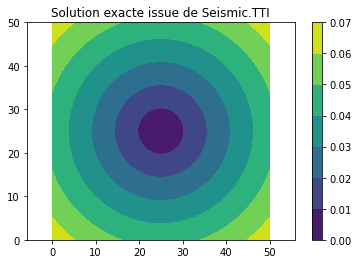

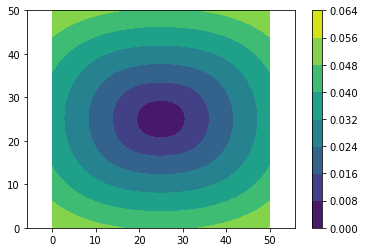

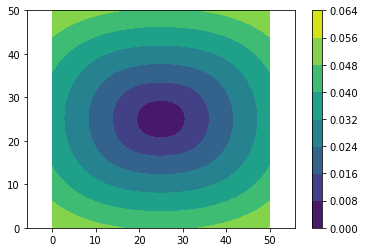

In [4]:
plt.title("Solution exacte issue de Seismic.TTI")
plt.contourf(exact1s[:,:,n//2])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf(exact1s[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf(exact1s[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

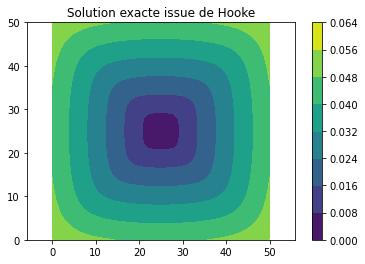

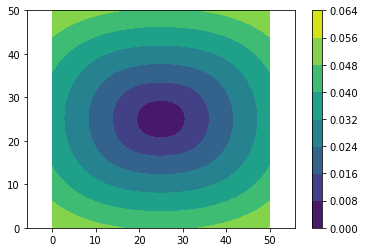

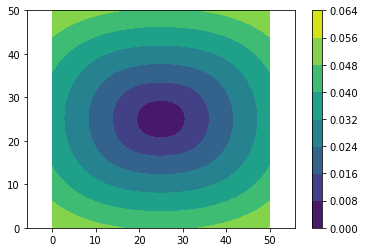

In [5]:
plt.title("Solution exacte issue de Hooke")
plt.contourf(exact2s[:,:,n//2])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf(exact2s[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf(exact2s[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

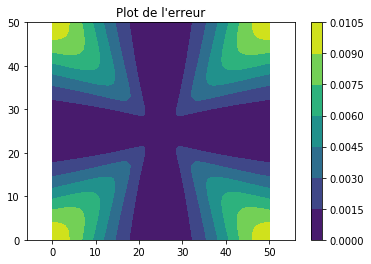

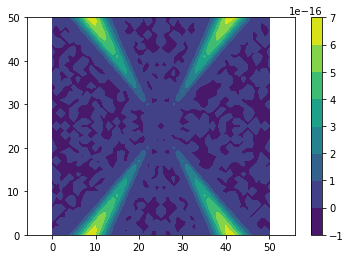

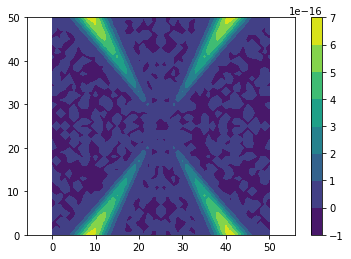

In [177]:
plt.title("Plot de l'erreur")
plt.contourf((exact1s-exact2s)[:,:,n//2]) #erreur
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact1s-exact2s)[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact1s-exact2s)[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

In [160]:
#erreur L2
np.sqrt(((exact1s-exact2s)**2).sum() / (exact2s**2).sum())

0.07945421938467072

## Comparaison Mica : OK, même résultat

In [161]:
metric1m = Seismic.TTI.mica[0]
metric2m = Hooke.mica[0] #solution correcte

exact1m = metric1m.norm((X,Y,Z))
exact2m = metric2m.norm((X,Y,Z))

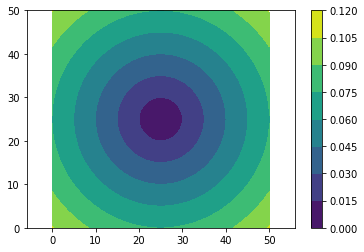

In [162]:
plt.contourf(exact1m[:,:,n//2])
plt.colorbar()
plt.axis('equal');

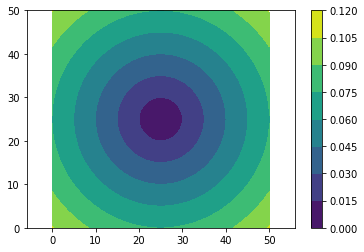

In [163]:
plt.contourf(exact2m[:,:,n//2])
plt.colorbar()
plt.axis('equal');

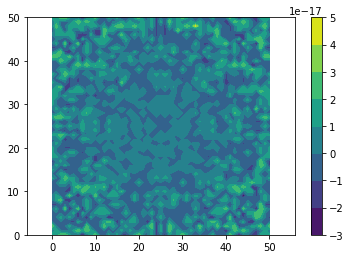

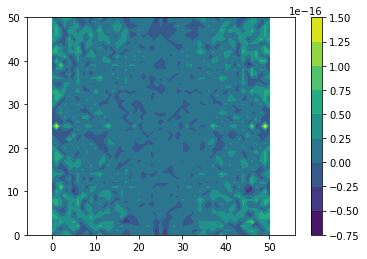

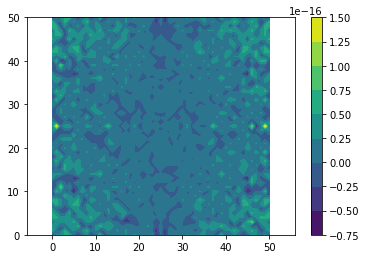

In [164]:
plt.contourf((exact1m-exact2m)[:,:,n//2])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact1m-exact2m)[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact1m-exact2m)[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

In [165]:
#erreur L2
np.sqrt(((exact1m-exact2m)**2).sum() / (exact2s**2).sum())

2.0981748080221855e-15

# Calcul solution TTI avec HFM

## Pour Mica sans rotation, OK

In [166]:
n = 51

hfmIn = Eikonal.dictIn({
    'order':2,
    'model':'TTI3',
    'arrayOrdering':'RowMajor',
    'exportValues':1,
    'seeds':[[0.,0.,0.]],
    'verbosity':0,
    'factoringRadius':-1
})

hfmIn.SetRect(sides=[[-1,1],[-1,1],[-1,1]],dimx=n)
X,Y,Z = hfmIn.Grid()

metric = Seismic.TTI.mica[0]

hfmIn['metric'] = metric

hfmOut = hfmIn.Run()

calc = hfmOut['values']

exact = metric.norm((X,Y,Z))

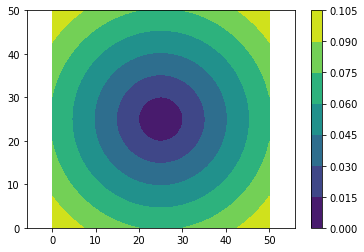

In [167]:
plt.contourf(calc[:,:,n//2])
plt.colorbar()
plt.axis('equal');

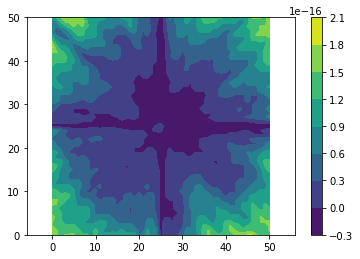

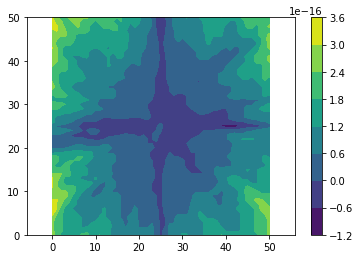

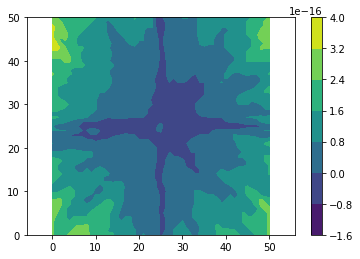

In [168]:
plt.contourf((exact-calc)[:,:,n//2])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact-calc)[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact-calc)[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

In [169]:
#erreur L2
np.sqrt(((exact-calc)**2).sum() / (exact**2).sum())

1.721127835087924e-15

## Pour Mica avec rotation : pas une bonne précision

In [11]:
n = 51

hfmIn = Eikonal.dictIn({
    'order':2,
    'model':'TTI3',
    'arrayOrdering':'RowMajor',
    'exportValues':1,
    'seeds':[[0.,0.,0.]],
    'verbosity':0,
    'factoringRadius':-1
})

hfmIn.SetRect(sides=[[-1,1],[-1,1],[-1,1]],dimx=n)
X,Y,Z = hfmIn.Grid()

rotation_params = (2*np.pi/5,(2.,1.,3.))
metric = Seismic.TTI.mica[0].rotate_by(*rotation_params) #rotation constante

hfmIn['metric'] = metric

hfmOut = hfmIn.Run()

calc = hfmOut['values']

exact = metric.norm((X,Y,Z))

Assertion failed: (a != ComponentType(0.)), function operator/=, file /Users/mirebeau/Dropbox/Programmes/Github/HamiltonFastMarching/JMM_CPPLibs/JMM_CPPLibs/LinearAlgebra/VectorType.h, line 38.
Returned with exit code  -6


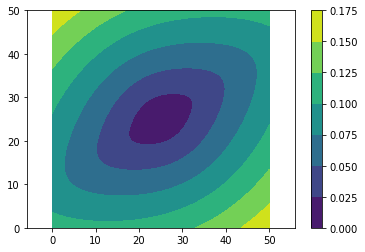

In [171]:
plt.contourf(calc[:,:,n//2])
plt.colorbar()
plt.axis('equal');

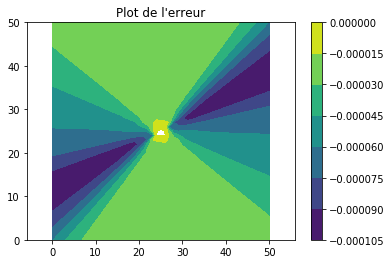

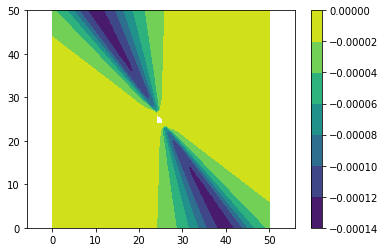

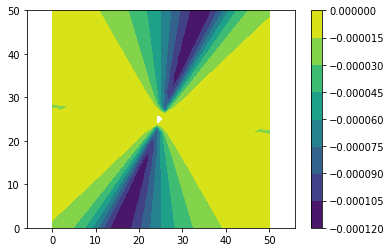

In [178]:
plt.title("Plot de l'erreur")
plt.contourf((exact-calc)[:,:,n//2])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact-calc)[:,n//2,:])
plt.colorbar()
plt.axis('equal')
plt.show();

plt.contourf((exact-calc)[n//2,:,:])
plt.colorbar()
plt.axis('equal')
plt.show();

In [173]:
#erreur L2
np.sqrt(((exact-calc)**2).sum() / (exact**2).sum())

0.00039397371093386586